In [ ]:
#import the required packages
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
import os


In [ ]:
#preparing the dataset for upload
from google.colab import files
import zipfile

uploaded = files.upload()

# Get the name of the uploaded file
zip_filename = next(iter(uploaded))

print(f"Uploaded file: {zip_filename}")


# Extract the uploaded zip file.
extract_path = "/content/dataset/"

with zipfile.ZipFile(zip_filename, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")


#list the folders in the extracted data from the zip file.
for root, dirs, files in os.walk(extract_path):
    print(root)



In [ ]:
# run this cell when the dataset folder has been uploaded to the google drive
from google.colab import drive
drive.mount('/content/drive')

extract_path = "/content/drive/MyDrive/brain_tumor_dataset"

Mounted at /content/drive


In [ ]:
#run this cell when you're getting the dataset directly from kaggle
import kagglehub

# Download latest version
extract_path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", extract_path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [ ]:
#settings
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5,],
        std=[0.5,]
    )
])

#select whether to use a cpu or gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

epochs = 5

In [ ]:
#load the data set

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader


train_dataset_path = os.path.join(extract_path, "Training")
test_dataset_path = os.path.join(extract_path, "Testing")

#NOTE: Path to the data set is the same as the extract path.
train_dataset = ImageFolder(root=train_dataset_path, transform=transform)
test_dataset = ImageFolder(root=test_dataset_path, transform=transform)

#generator = torch.Generator().manual_seed(42)
#load the test and train data into a DataLoader

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
labels = train_dataset.classes
print(labels)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
print('Classes/Labels: ', labels)


print('Train Images: ', len(train_dataset))
print("Test images:", len(test_dataset))

Classes/Labels:  ['glioma', 'meningioma', 'notumor', 'pituitary']
Train Images:  5600
Test images: 1600


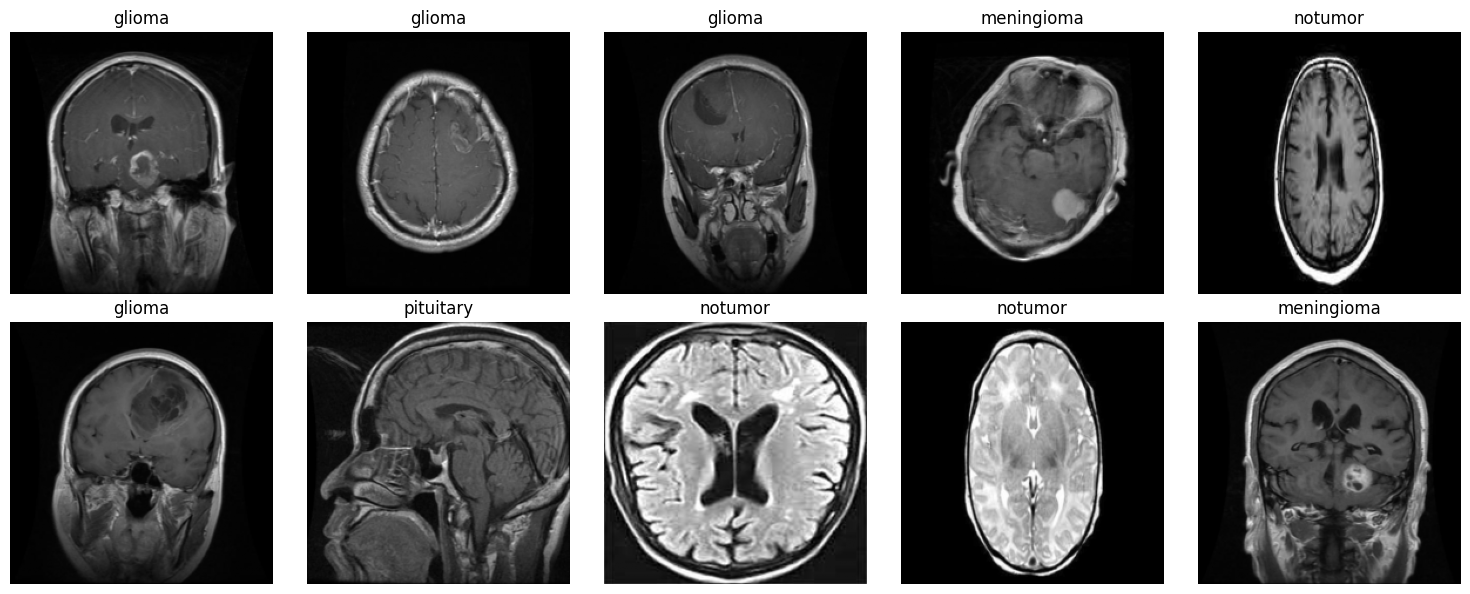

In [ ]:
import matplotlib.pyplot as plt
import random

# Get 10 samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):

    image, label = train_dataset[random.randint(0, len(train_dataset))]

    # Undo normalization: (image * std) + mean
    image = image * 0.5 + 0.5

    # Convert from Tensor [C,H,W] to numpy [H,W,C]
    image = image.squeeze().numpy()

    ax.imshow(image, cmap="gray")
    ax.set_title(labels[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:

import torch.nn as nn
import torch.optim as optim

#building our neural network
class CNN(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv = nn.Sequential(
        nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1
        ),

        nn.ReLU(), # add non linearity

        nn.MaxPool2d(2),

        nn.Conv2d(
            32,
            64,
            kernel_size=3,
            padding=1
        ),

        nn.ReLU(), #another non linearity

        nn.MaxPool2d(2)
    )

    self.fc = nn.Sequential(
        nn.Flatten(),

        nn.Linear(
          64 * 56 * 56,
          128
        ),

        nn.ReLU(),

        nn.Linear(
            128,
            4
        )
    )


  def forward(self, x):
    x = self.conv(x)
    x = self.fc(x)

    return x




In [ ]:
#create the model
model = CNN()

print(model)

#define the loss function
criterion = nn.CrossEntropyLoss()

#define the optimizer function
optimizer = optim.Adam(model.parameters(), lr=0.001)

CNN(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=200704, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=4, bias=True)
  )
)


In [ ]:


train_losses = []
train_accuracies = []

#train the model

for epoch in range(epochs):

  model.train()

  running_loss = 0
  correct = 0
  total = 0

  for images, labels in train_loader:

    images = images.to(device)
    labels = labels.to(device)

    # Reset gradients
    optimizer.zero_grad()

    # Forward pass
    outputs = model(images)

    # Compute loss
    loss = criterion(outputs, labels)

    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

    running_loss += loss.item()

    _, predicted = torch.max(outputs, 1)

    total += labels.size(0)
    correct += (predicted == labels).sum().item()

  epoch_loss = running_loss / len(train_loader)
  epoch_accuracy = 100 * correct / total

  train_losses.append(epoch_loss)
  train_accuracies.append(epoch_accuracy)

  print(
    f"Epoch {epoch+1}/{epochs} | "
    f"Loss: {epoch_loss:.4f} | "
    f"Accuracy: {epoch_accuracy:.2f}%"
  )

Epoch 1/5 | Loss: 1.4486 | Accuracy: 69.34%
Epoch 2/5 | Loss: 0.3181 | Accuracy: 88.27%
Epoch 3/5 | Loss: 0.1878 | Accuracy: 93.45%
Epoch 4/5 | Loss: 0.0928 | Accuracy: 96.84%
Epoch 5/5 | Loss: 0.0478 | Accuracy: 98.61%


In [ ]:
model.eval()

CNN(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=200704, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=4, bias=True)
  )
)

In [ ]:
correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, _labels in test_loader:

        images = images.to(device)
        _labels = _labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += _labels.size(0)
        correct += (predicted == _labels).sum().item()

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(_labels.numpy())


accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 86.38%


All Labels SIze:  1600
All Predictions size:  1600


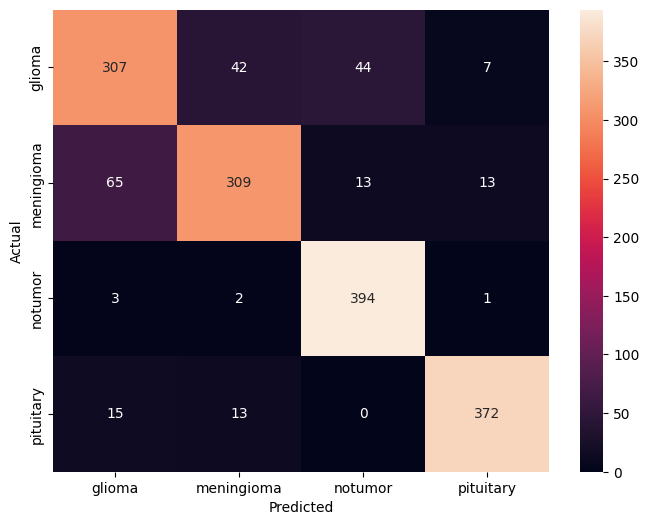

In [ ]:

print('All Labels SIze: ', len(all_labels))
print('All Predictions size: ', len(all_predictions))

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#building a confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=train_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
#classification report
from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_predictions,
    target_names=train_dataset.classes
)

print(report)

              precision    recall  f1-score   support

      glioma       0.79      0.77      0.78       400
  meningioma       0.84      0.77      0.81       400
     notumor       0.87      0.98      0.93       400
   pituitary       0.95      0.93      0.94       400

    accuracy                           0.86      1600
   macro avg       0.86      0.86      0.86      1600
weighted avg       0.86      0.86      0.86      1600



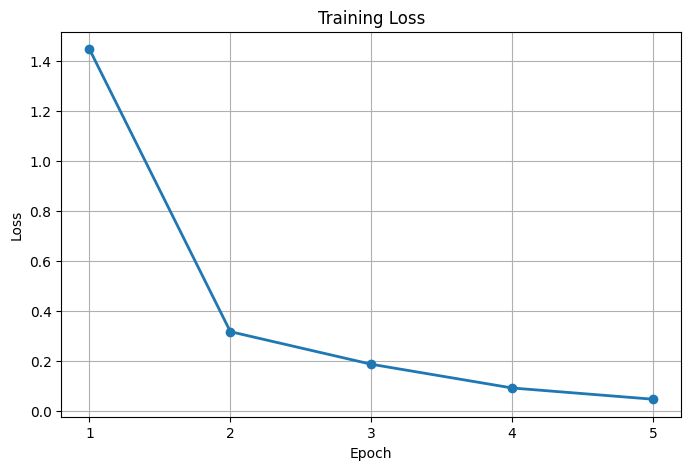

In [ ]:
#plot the loss curve
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, marker='o', linewidth=2)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.grid(True)
plt.show()

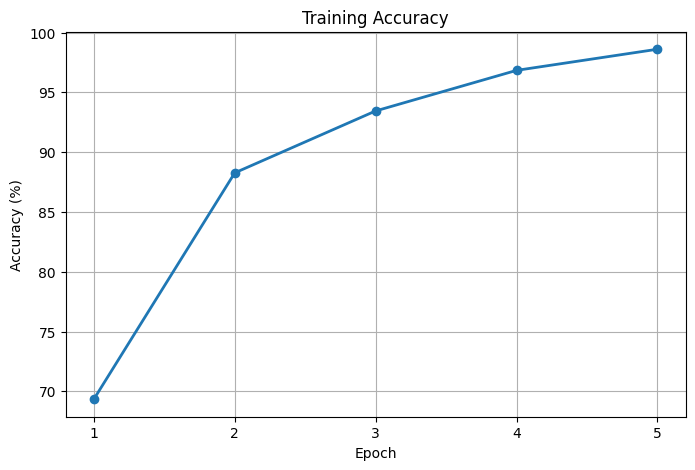

In [ ]:
#the accuracy curve
plt.figure(figsize=(8,5))
plt.plot(epochs, train_accuracies, marker='o', linewidth=2)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(epochs)
plt.grid(True)
plt.show()

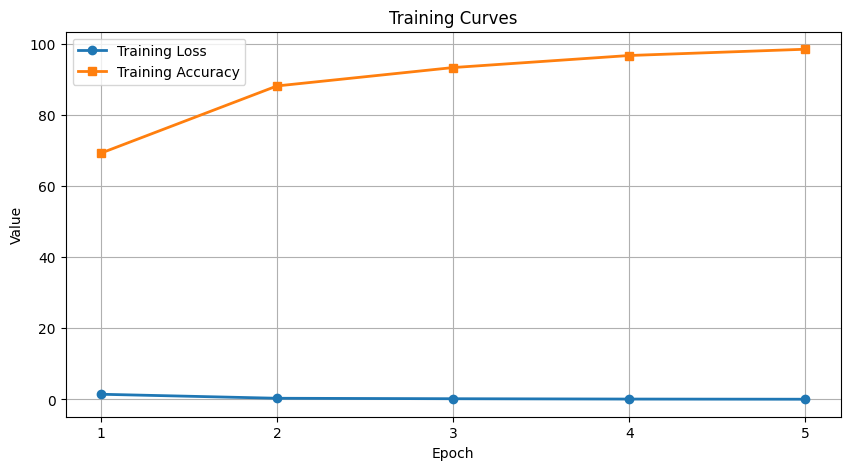

In [ ]:
#plot both the loss the accuracy in one curve
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(epochs, train_losses, marker='o', linewidth=2, label="Training Loss")
ax.plot(epochs, train_accuracies, marker='s', linewidth=2, label="Training Accuracy")

ax.set_title("Training Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Value")
ax.set_xticks(list(epochs))
ax.grid(True)
ax.legend()

plt.show()

In [ ]:
#save the model
from google.colab import drive
drive.mount('/content/drive')
model_file_path = '/content/drive/MyDrive/brain-tumor-mri-cnn.pth'
torch.save(model.state_dict(), model_file_path)

Mounted at /content/drive


In [23]:
#download the model
from google.colab import files
files.download(model_file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>